In [1]:
from glob import glob

import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader

from compgen.model.composition_model import CompositionModel
from compgen.data.dataset import CompositionDataset
from compgen.train.trainer import Trainer

In [2]:
# Dataset.
dataset =  CompositionDataset(data_path= './data/mp_20/train.csv')

train_loader = DataLoader(
    dataset,
    batch_size = 32,
    pin_memory = True,
    shuffle = True,
)

In [3]:
# Model.
composition_model = CompositionModel(
    elem_emb_len=200, 
    elem_fea_len=32, 
    n_graph = 3,
    elem_heads=3,
    elem_gate=[64],
    elem_msg=[64],
    cry_heads=3,
    cry_gate=[64],
    cry_msg=[64],
    activation = nn.SiLU,
    batchnorm = False,
)

In [4]:
trainer = Trainer(
    model=composition_model,
    optimizer='Adam',
    epochs = 10,
    learning_rate=1e-4,
    print_freq=30,
    torch_seed=42,
    data_seed=42,
    weight_decay=1e-6,
)

In [5]:
trainer.train(train_loader)

Begin Training: using cuda device


Epoch: [1][1/848]	Time (1.055) Data (0.063) Loss 0.9314 (0.9314) KL Loss 0.0091 (0.0091) Comp Loss 0.0034 (0.0034) Ave V Loss 0.9189 (0.9189)
Epoch: [1][30/848]	Time (0.152) Data (0.067) Loss 0.5110 (0.8489) KL Loss 0.0079 (0.0085) Comp Loss 0.0032 (0.0033) Ave V Loss 0.4999 (0.8371)
Epoch: [1][60/848]	Time (0.132) Data (0.065) Loss 1.1471 (0.9290) KL Loss 0.0068 (0.0079) Comp Loss 0.0034 (0.0034) Ave V Loss 1.1369 (0.9177)
Epoch: [1][90/848]	Time (0.126) Data (0.065) Loss 1.2720 (0.9240) KL Loss 0.0058 (0.0074) Comp Loss 0.0035 (0.0034) Ave V Loss 1.2627 (0.9133)
Epoch: [1][120/848]	Time (0.125) Data (0.067) Loss 0.5083 (0.9209) KL Loss 0.0048 (0.0068) Comp Loss 0.0036 (0.0034) Ave V Loss 0.4999 (0.9107)
Epoch: [1][150/848]	Time (0.121) Data (0.065) Loss 0.5630 (0.8942) KL Loss 0.0039 (0.0064) Comp Loss 0.0032 (0.0034) Ave V Loss 0.5560 (0.8844)
Epoch: [1][180/848]	Time (0.120) Data (0.065) Loss 0.3297 (0.8686) KL Loss 0.0045 (0.0059) Comp Loss 0.0033 (0.0034) Ave V Loss 0.3219 (0.859

In [20]:
# Sample new compositions.
model_path = glob('./*/best*')[0]
composition_model = CompositionModel.from_file(model_path)
composition_model.v_scaler = dataset.v_scaler
comp, atom_types, formulas = composition_model.sample_comp(num_samples=60, num_atoms=5)
atom_types = torch.stack(atom_types, dim=0)
comp, atom_types, formulas

/home/xzdai/anaconda3/envs/chggen/lib/python3.8/site-packages/pymatgen/core/periodic_table.py:221: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  warnings.warn(


(tensor([[0.0079, 0.0041, 0.0252,  ..., 0.0042, 0.0041, 0.0044],
         [0.0087, 0.0041, 0.0257,  ..., 0.0042, 0.0041, 0.0042],
         [0.0068, 0.0033, 0.0254,  ..., 0.0033, 0.0032, 0.0034],
         ...,
         [0.0063, 0.0036, 0.0212,  ..., 0.0036, 0.0035, 0.0037],
         [0.0068, 0.0039, 0.0231,  ..., 0.0040, 0.0040, 0.0041],
         [0.0084, 0.0047, 0.0225,  ..., 0.0049, 0.0047, 0.0049]]),
 tensor([[  9,  34,   3,  44,  90],
         [ 88,  57,   3,  35,  51],
         [ 59,  92,  66,  25,  92],
         [ 26,  25,  37,  15,  23],
         [ 16,   9,  22,  11,  27],
         [ 66,  64,  28,  64,  42],
         [ 42,  51,  27,  55,  14],
         [ 35,  27,  29,  36,  27],
         [ 82,  28,  33,  94,  86],
         [ 23,   7,  55,   9,  76],
         [ 26,   2,  39,  41, 102],
         [ 27, 103,  81,  39,  44],
         [ 44,  63,  50,  15,  80],
         [ 29,  13,  76,  46,  87],
         [102,  46, 102,  57,   3],
         [ 41,  12,  97,  57,  26],
         [ 23,  16

In [18]:
# Estimate ave_v for sampled dataset.

sampled_dataset = CompositionDataset.from_formulas(formulas = formulas)
sampled_loader = DataLoader(sampled_dataset)

ave_v = []
for batch in sampled_loader:
    ave_v.append(composition_model.predict_ave_v(batch))
ave_v = torch.cat(ave_v, dim=0)
ave_v

tensor([[11.7488],
        [16.4921],
        [16.2936],
        [16.0712],
        [20.3756],
        [16.8062],
        [22.0149],
        [16.0731],
        [22.4454],
        [13.6582],
        [27.5086],
        [20.7304],
        [19.1447],
        [15.1467],
        [16.6558],
        [21.7251],
        [11.4846],
        [19.6251],
        [20.5002],
        [21.7751],
        [18.3756],
        [20.7198],
        [24.5682],
        [20.2500],
        [28.3387],
        [27.9002],
        [18.1227],
        [19.3133],
        [21.5436],
        [19.0277],
        [19.6626],
        [17.3373],
        [23.9224],
        [17.3257],
        [25.5751],
        [18.8754],
        [16.8413],
        [22.1336],
        [20.0295],
        [24.7604],
        [20.5050],
        [11.7341],
        [24.2495],
        [15.1162],
        [23.1871],
        [22.2796],
        [21.5784],
        [17.5642],
        [19.6646],
        [32.8153],
        [19.3756],
        [21.7319],
        [22.

### Dimensionality Reduction
1. PCA
2. t-SNE

In [21]:
from tqdm import tqdm
model_path = glob('./*/best*')[0]
composition_model = CompositionModel.from_file(model_path).to('cuda')
composition_model.v_scaler = dataset.v_scaler

mus = []
for batch in tqdm(train_loader):
    mu, _ = composition_model.encode(batch.cuda())
    mus.append(mu)
mus = torch.cat(mus, dim=0)

100%|██████████| 848/848 [00:07<00:00, 106.52it/s]


In [22]:
# Dataset.
dataset_LiMnO =  CompositionDataset(data_path= './data/LiMnO.csv')

train_loader_LiMnO = DataLoader(
    dataset_LiMnO,
    batch_size = 32,
    pin_memory = True,
    shuffle = True,
)

mus_LiMnO = []
for batch in tqdm(train_loader_LiMnO):
    mu, _ = composition_model.encode(batch.cuda())
    mus_LiMnO.append(mu)
mus_LiMnO = torch.cat(mus_LiMnO, dim=0)

100%|██████████| 1/1 [00:00<00:00, 33.42it/s]


In [23]:
# Dataset.
dataset_CdS =  CompositionDataset(data_path= './data/CdS.csv')

train_loader_CdS = DataLoader(
    dataset_CdS,
    batch_size = 32,
    pin_memory = True,
    shuffle = True,
)

mus_CdS = []
for batch in tqdm(train_loader_CdS):
    mu, _ = composition_model.encode(batch.cuda())
    mus_CdS.append(mu)
mus_CdS = torch.cat(mus_CdS, dim=0)

100%|██████████| 1/1 [00:00<00:00, 28.88it/s]


In [24]:
# Dataset.
dataset_VO =  CompositionDataset(data_path= './data/VO.csv')

train_loader_VO = DataLoader(
    dataset_VO,
    batch_size = 32,
    pin_memory = True,
    shuffle = True,
)

mus_VO = []
for batch in tqdm(train_loader_VO):
    mu, _ = composition_model.encode(batch.cuda())
    mus_VO.append(mu)
mus_VO = torch.cat(mus_VO, dim=0)

100%|██████████| 1/1 [00:00<00:00, 26.31it/s]


In [52]:
# PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
mus_pca = pca.fit_transform(mus.cpu().detach().numpy())
mus_pca_LiMnO = pca.transform(mus_LiMnO.cpu().detach().numpy())
mus_pca_CdS = pca.transform(mus_CdS.cpu().detach().numpy())
mus_pca_VO = pca.transform(mus_VO.cpu().detach().numpy())

print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[0.49768034 0.18524861]
[0.552686   0.33719465]


(-0.01, 0.01)

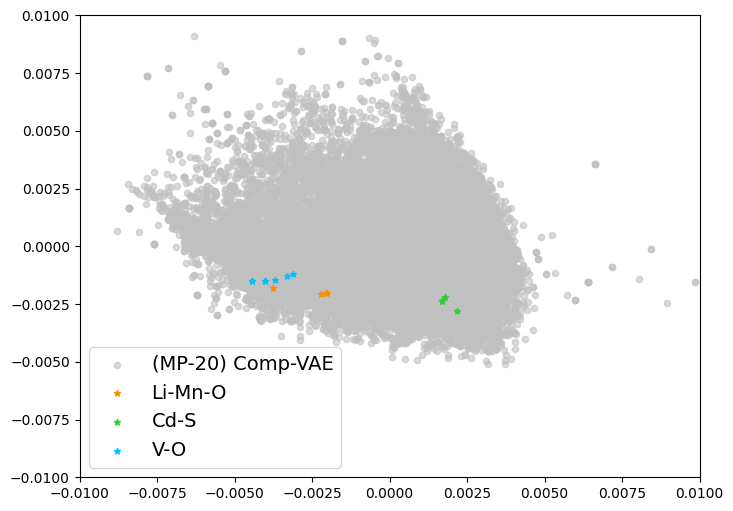

In [56]:
plt.figure(figsize=(8,6))
plt.scatter(mus_pca[:,0], mus_pca[:,1], s=20, color='silver', marker="o", alpha=0.6, label="(MP-20) Comp-VAE")
plt.scatter(mus_pca_LiMnO[:,0], mus_pca_LiMnO[:,1], s=20, marker='*', color="darkorange", alpha=1.0, label="Li-Mn-O")
plt.scatter(mus_pca_CdS[:,0], mus_pca_CdS[:,1], s=20, marker='*', color="limegreen", alpha=1.0, label="Cd-S")
plt.scatter(mus_pca_VO[:,0], mus_pca_VO[:,1], s=20, marker='*', color="deepskyblue", alpha=1.0, label="V-O")
plt.legend(fontsize=14)
# plt.axis('off')
plt.xlim(-0.01, 0.01)
plt.ylim(-0.01, 0.01)

In [49]:
ids = mus_pca[:,0].argsort()[-10:]
outliers = []
for id in ids:
    outliers.append(dataset[id])
outliers

[Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 103], ave_v=[1], cry_id='mp-1103155', cry_name='LaSiRh'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 103], ave_v=[1], cry_id='mp-1184109', cry_name='DyTmCu2'),
 Data(x=[2, 200], edge_index=[2, 4], elem_weights=[2, 1], comp=[1, 103], ave_v=[1], cry_id='mp-1101660', cry_name='Nb2O5'),
 Data(x=[4, 200], edge_index=[2, 16], elem_weights=[4, 1], comp=[1, 103], ave_v=[1], cry_id='mp-560129', cry_name='Na3La2(BO3)3'),
 Data(x=[2, 200], edge_index=[2, 4], elem_weights=[2, 1], comp=[1, 103], ave_v=[1], cry_id='mp-1102295', cry_name='YbRu2'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 103], ave_v=[1], cry_id='mp-20024', cry_name='LaCuSn'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 103], ave_v=[1], cry_id='mp-570653', cry_name='LaFe5H12'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 103], ave_v=[1], cry_id='mp-1185260', cry_name='LiNi2S

In [50]:
ids = mus_pca[:,0].argsort()[:10]
outliers = []
for id in ids:
    outliers.append(dataset[id])
outliers

[Data(x=[4, 200], edge_index=[2, 16], elem_weights=[4, 1], comp=[1, 103], ave_v=[1], cry_id='mp-556386', cry_name='KNa3WO5'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 103], ave_v=[1], cry_id='mp-1217195', cry_name='Ti5Nb5Ge6'),
 Data(x=[2, 200], edge_index=[2, 4], elem_weights=[2, 1], comp=[1, 103], ave_v=[1], cry_id='mp-1229015', cry_name='AgPt'),
 Data(x=[2, 200], edge_index=[2, 4], elem_weights=[2, 1], comp=[1, 103], ave_v=[1], cry_id='mp-2165', cry_name='SmZn'),
 Data(x=[2, 200], edge_index=[2, 4], elem_weights=[2, 1], comp=[1, 103], ave_v=[1], cry_id='mp-568959', cry_name='La4As3'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 103], ave_v=[1], cry_id='mp-1223871', cry_name='K4NaCl5'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 103], ave_v=[1], cry_id='mp-1102291', cry_name='La3TaO7'),
 Data(x=[3, 200], edge_index=[2, 9], elem_weights=[3, 1], comp=[1, 103], ave_v=[1], cry_id='mp-567214', cry_name='NdSnRh'),
 Da

In [ ]:
# t-SNE.
from sklearn.manifold import TSNE
t_sne =  TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=20, verbose=1)
mus_tsne = t_sne.fit_transform(mus.cpu().detach().numpy())

In [ ]:
plt.scatter(mus_tsne[:, 0], mus_tsne[:, 1], s=5)